# 개업률 ↔ 유동인구 변화율 분석
- 목적: 유동인구 변화율과 개업률의 관계 확인 → 포화 상권 / 고위험 상권 도출
- 데이터: 소희(점포_합본) × 정연(길단위인구)
- 분석 기간: 2019 ~ 2024년

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 (Windows: Malgun Gothic / Mac: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

##  데이터 로드

In [2]:
# 소희님 점포 합본 (개업률 계산용)
df_점포 = pd.read_csv('../data/점포_합본.csv', encoding='utf-8-sig')

# 정연님 길단위인구 (유동인구 변화율 계산용)
df_인구 = pd.read_csv(
    '../data/05_길단위인구/서울시 상권분석서비스(길단위인구-상권).csv',
    encoding='cp949'
)

# 분석 기간 필터링 (2024년까지)
df_인구 = df_인구[df_인구['기준_년분기_코드'] < 20250]

print(f'점포 데이터: {df_점포.shape}')
print(f'유동인구 데이터: {df_인구.shape}')
print(f'\n점포 컬럼: {df_점포.columns.tolist()}')

점포 데이터: (1831925, 15)
유동인구 데이터: (39589, 27)

점포 컬럼: ['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '서비스_업종_코드', '서비스_업종_코드_명', '점포_수', '유사_업종_점포_수', '개업_율', '개업_점포_수', '폐업_률', '폐업_점포_수', '프랜차이즈_점포_수', '연도']


## 개업률 계산
- 점포 데이터는 업종별로 쪼개져 있음 → 연도 + 상권 기준으로 합산 먼저
- 개업률 = 개업_점포_수 합계 / 점포_수 합계 × 100

In [3]:
# 업종별 → 상권별 합산
df_점포_집계 = df_점포.groupby(['연도', '상권_코드', '상권_구분_코드_명']).agg(
    총점포수=('점포_수', 'sum'),
    총개업수=('개업_점포_수', 'sum')
).reset_index()

# 개업률 계산
df_점포_집계['개업률'] = (
    df_점포_집계['총개업수'] / df_점포_집계['총점포수'] * 100
).round(2)

print(f'집계 후: {df_점포_집계.shape}')
print(f'기간: {sorted(df_점포_집계["연도"].unique())}')
df_점포_집계.head()

집계 후: (9900, 6)
기간: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,연도,상권_코드,상권_구분_코드_명,총점포수,총개업수,개업률
0,2019,3001491,관광특구,6421,255,3.97
1,2019,3001492,관광특구,35239,1070,3.04
2,2019,3001493,관광특구,58503,2245,3.84
3,2019,3001494,관광특구,18037,437,2.42
4,2019,3001495,관광특구,10788,568,5.27


## 유동인구 전년도 대비 변화율 계산
- 분기별 데이터를 연도 평균으로 먼저 합산
- 전년도 대비 변화율: pct_change() 사용

In [4]:
# 연도 컬럼 추가 (기준_년분기_코드 앞 4자리 추출)
df_인구['연도'] = df_인구['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 분기별 데이터 → 연도별 평균으로 합산
# (같은 상권이 1년에 4개 분기 데이터 있으므로 평균 냄)
df_인구_집계 = df_인구.groupby(['연도', '상권_코드', '상권_구분_코드_명']).agg(
    평균_유동인구=('총_유동인구_수', 'mean')
).reset_index()

# 전년도 대비 유동인구 변화율 계산
# groupby('상권_코드') 안에서 계산해야 다른 상권끼리 안 섞임
df_인구_집계['유동인구_변화율'] = (
    df_인구_집계
    .groupby('상권_코드')['평균_유동인구']
    .pct_change() * 100  # pct_change() = 전년도 대비 증감률 / 첫 연도는 NaN
)

print(f'유동인구 집계: {df_인구_집계.shape}')
df_인구_집계.head(10)

유동인구 집계: (9899, 5)


,연도,상권_코드,상권_구분_코드_명,평균_유동인구,유동인구_변화율
0,2019,3001491,관광특구,2438319.00,NaN
1,2019,3001492,관광특구,8164084.00,NaN
2,2019,3001493,관광특구,3820540.75,NaN
3,2019,3001494,관광특구,10669713.25,NaN
4,2019,3001495,관광특구,3760889.75,NaN
5,2019,3001496,관광특구,122969.75,NaN
6,2019,3110001,골목상권,138091.75,NaN
7,2019,3110002,골목상권,543306.25,NaN
8,2019,3110003,골목상권,637494.50,NaN
9,2019,3110004,골목상권,532729.25,NaN


##  데이터 합치기 (JOIN)
- 연도 + 상권_코드 기준으로 개업률 + 유동인구 변화율 연결
- 2019년 유동인구 변화율은 NaN이라 제거

In [5]:
# 연도 + 상권_코드 기준으로 합치기
df_합 = pd.merge(
    df_점포_집계,
    df_인구_집계[['연도', '상권_코드', '평균_유동인구', '유동인구_변화율']],
    on=['연도', '상권_코드'],
    how='inner'  # 두 데이터에 모두 있는 상권만 유지 (한쪽에만 있으면 제외)
)

# 2019년은 전년도 데이터 없어서 변화율이 NaN → 제거
df_합 = df_합.dropna(subset=['유동인구_변화율'])

print(f'합친 데이터: {df_합.shape}')
print(f'기간: {sorted(df_합["연도"].unique())}')
df_합.head()

합친 데이터: (8249, 8)
기간: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,연도,상권_코드,상권_구분_코드_명,총점포수,총개업수,개업률,평균_유동인구,유동인구_변화율
1650,2020,3001491,관광특구,6312,189,2.99,1788592.25,-26.646503
1651,2020,3001492,관광특구,34962,686,1.96,6208642.00,-23.951762
1652,2020,3001493,관광특구,60037,1635,2.72,3189657.75,-16.512924
1653,2020,3001494,관광특구,18020,390,2.16,8331618.50,-21.913379
1654,2020,3001495,관광특구,11671,496,4.25,3477993.25,-7.522063


##  상권 유형별 개업률 vs 유동인구 변화율 시각화

In [6]:
# 연도별 + 상권 유형별 평균 계산
연도별 = df_합.groupby(['연도', '상권_구분_코드_명']).agg(
    개업률=('개업률', 'mean'),
    유동인구_변화율=('유동인구_변화율', 'mean')
).reset_index()

print(연도별.round(2))

      연도 상권_구분_코드_명   개업률  유동인구_변화율
0   2020       골목상권  3.81      0.48
1   2020       관광특구  2.87    -19.95
2   2020       발달상권  3.70     -6.00
3   2020       전통시장  3.71     -3.96
4   2021       골목상권  3.47     -3.09
5   2021       관광특구  2.49     -0.75
6   2021       발달상권  3.42     -2.51
7   2021       전통시장  2.88     -4.68
8   2022       골목상권  3.33     -1.88
9   2022       관광특구  2.61     12.04
10  2022       발달상권  3.23      4.46
11  2022       전통시장  2.70     -0.47
12  2023       골목상권  3.63     -1.04
13  2023       관광특구  2.60      1.86
14  2023       발달상권  3.33      1.56
15  2023       전통시장  2.86     -0.91
16  2024       골목상권  2.66      0.71
17  2024       관광특구  1.57     -0.43
18  2024       발달상권  2.59      0.03
19  2024       전통시장  2.51      0.21


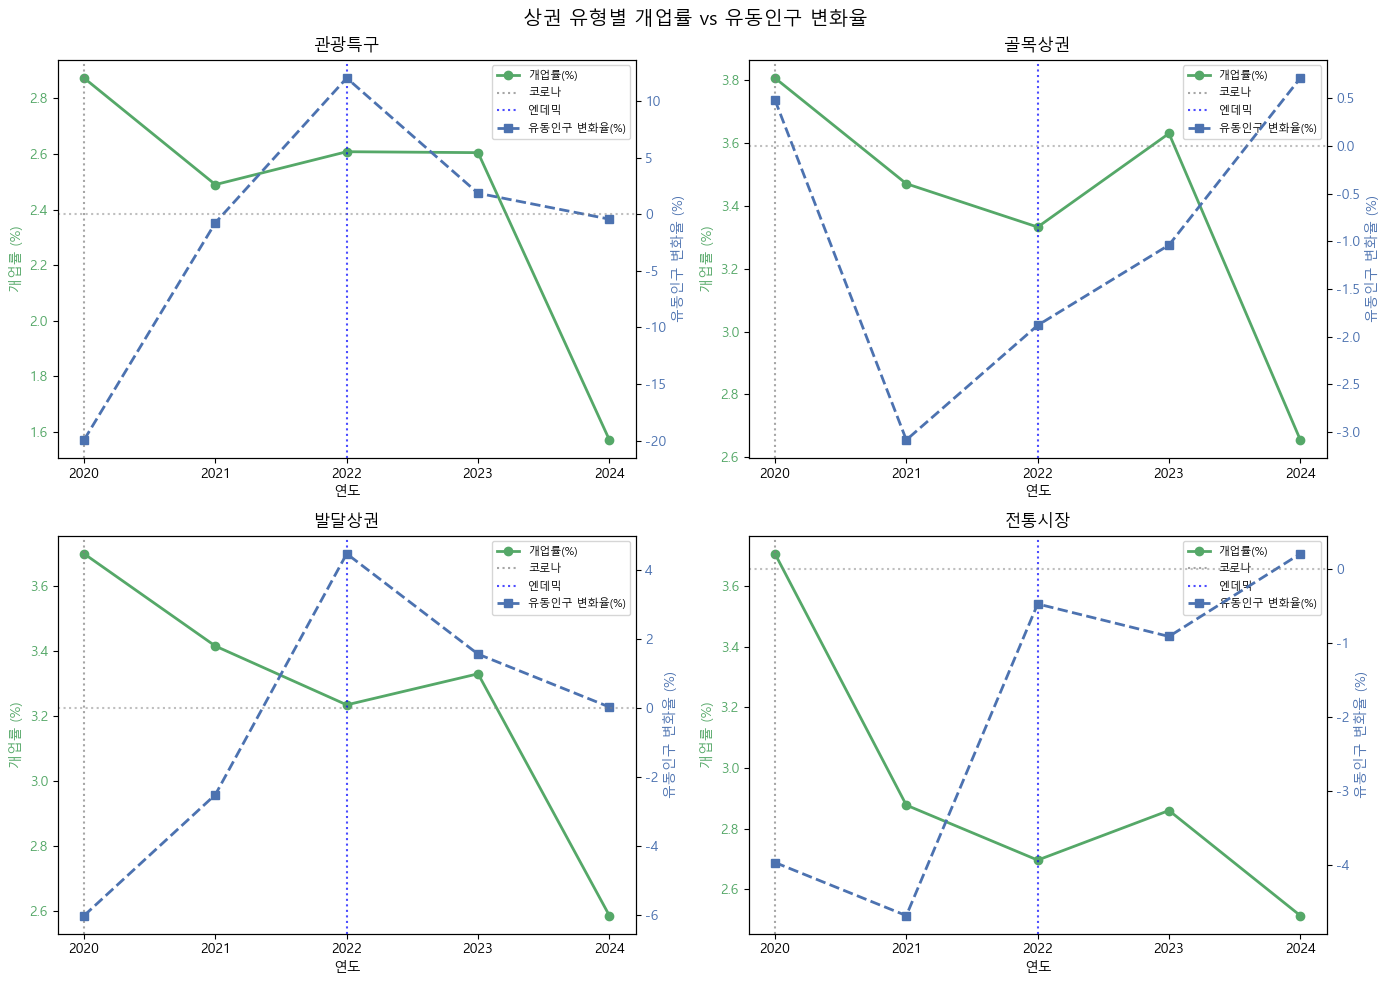

In [7]:
# 상권 유형 4개를 2x2 배치로 한 번에 비교
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 2x2 배열을 1줄로 펴기 (인덱스로 접근하기 위해)
axes = axes.flatten()

상권_목록 = ['관광특구', '골목상권', '발달상권', '전통시장']

for i, 유형 in enumerate(상권_목록):
    # 해당 유형 데이터만 필터링
    df_유형 = 연도별[연도별['상권_구분_코드_명'] == 유형]

    ax1 = axes[i]
    ax2 = ax1.twinx()  # 오른쪽 축 추가 (단위 다른 두 지표 같이 보기)

    # 왼쪽 축: 개업률 (초록)
    ax1.plot(df_유형['연도'], df_유형['개업률'],
             marker='o', color='#55A868', linewidth=2, label='개업률(%)')
    ax1.set_ylabel('개업률 (%)', color='#55A868')
    ax1.tick_params(axis='y', labelcolor='#55A868')

    # 오른쪽 축: 유동인구 변화율 (파랑)
    ax2.plot(df_유형['연도'], df_유형['유동인구_변화율'],
             marker='s', color='#4C72B0', linewidth=2,
             linestyle='--', label='유동인구 변화율(%)')
    ax2.set_ylabel('유동인구 변화율 (%)', color='#4C72B0')
    ax2.tick_params(axis='y', labelcolor='#4C72B0')
    ax2.axhline(y=0, color='gray', linestyle=':', alpha=0.5)  # 0% 기준선

    # 코로나/엔데믹 시점 표시
    ax1.axvline(x=2020, color='gray', linestyle=':', alpha=0.7, label='코로나')
    ax1.axvline(x=2022, color='blue', linestyle=':', alpha=0.7, label='엔데믹')

    ax1.set_title(f'{유형}', fontsize=12)
    ax1.set_xlabel('연도')
    
    # x축 소수점 제거 (정수 연도만 표시)
    ax1.set_xticks([2020, 2021, 2022, 2023, 2024])

    # 두 축 범례 합치기
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

plt.suptitle('상권 유형별 개업률 vs 유동인구 변화율', fontsize=14)
plt.tight_layout()
plt.show()

## 인사이트
- 관광특구: 2022년 엔데믹으로 유동인구 회복됐으나 개업률은 하락
  → 유동인구와 개업률이 반대로 움직임 = 임대료 부담으로 진입장벽 높은 상권
- 전 상권 2024년 개업률 최저점
  → 코로나 종료 이후에도 개업률 지속 하락 = 경기 위축 영향

##  유동인구 변화율 구간별 개업률 비교
- 유동인구가 늘었을 때 / 줄었을 때 개업률이 어떻게 달라지는지 확인

In [8]:
# 유동인구 변화율을 3구간으로 나누기
def 변화율_구간(x):
    if x < -5:      # 전년도보다 5% 이상 감소
        return '감소 (-5% 미만)'
    elif x <= 5:    # -5% ~ +5% 사이 (거의 변화 없음)
        return '유지 (-5%~+5%)'
    else:           # 전년도보다 5% 이상 증가
        return '증가 (+5% 초과)'

df_합['유동인구_구간'] = df_합['유동인구_변화율'].apply(변화율_구간)

# 구간 순서 고정 (그래프 정렬용)
구간_순서 = ['감소 (-5% 미만)', '유지 (-5%~+5%)', '증가 (+5% 초과)']
df_합['유동인구_구간'] = pd.Categorical( # 순서 고정
    df_합['유동인구_구간'], categories=구간_순서, ordered=True
)

# 구간별 데이터 수 확인
print('유동인구 구간별 데이터 수:')
print(df_합['유동인구_구간'].value_counts().sort_index())

유동인구 구간별 데이터 수:
유동인구_구간
감소 (-5% 미만)     2972
유지 (-5%~+5%)    3111
증가 (+5% 초과)     2166
Name: count, dtype: int64


In [9]:
# 유동인구 구간 × 상권 유형별 평균 개업률 계산
pivot = df_합.groupby(
    ['유동인구_구간', '상권_구분_코드_명']
)['개업률'].mean().unstack()

# 숫자 먼저 확인
print(pivot.round(2))

상권_구분_코드_명    골목상권  관광특구  발달상권  전통시장
유동인구_구간                             
감소 (-5% 미만)   3.37  2.87  3.29  2.99
유지 (-5%~+5%)  3.33  2.20  3.16  2.84
증가 (+5% 초과)   3.46  2.69  3.39  2.94


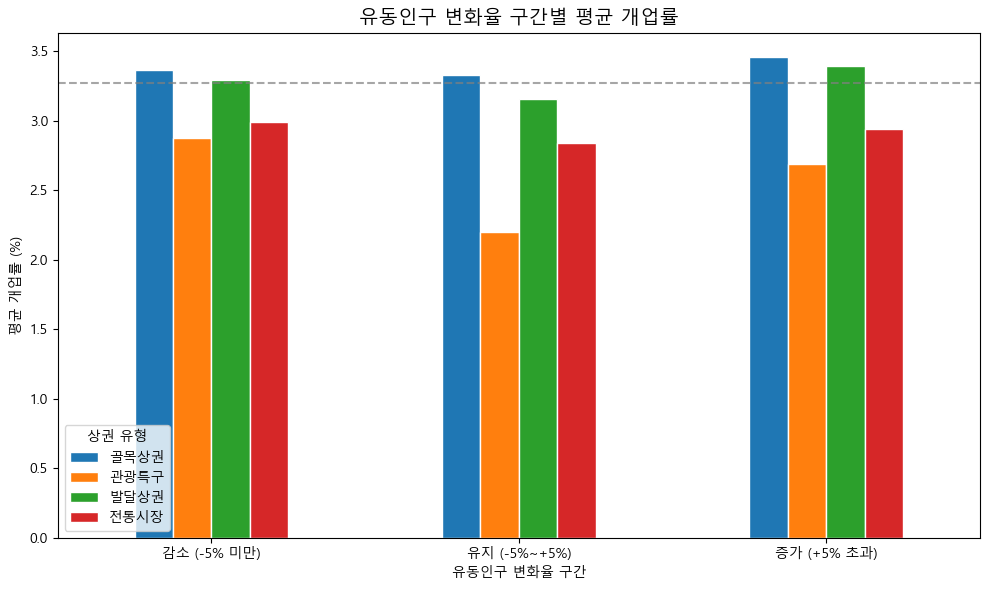

In [10]:
# 유동인구 구간별 상권 유형별 평균 개업률 막대그래프
pivot.plot(kind='bar', figsize=(10, 6), edgecolor='white')

plt.title('유동인구 변화율 구간별 평균 개업률', fontsize=14)
plt.xlabel('유동인구 변화율 구간')
plt.ylabel('평균 개업률 (%)')
plt.xticks(rotation=0)  # x축 라벨 가로로
plt.legend(title='상권 유형')
# 전체 평균 기준선
plt.axhline(y=df_합['개업률'].mean(), color='gray',
            linestyle='--', alpha=0.7, label='전체 평균')
plt.tight_layout()
plt.show()

##  인사이트
- 골목상권: 유동인구 변화율과 무관하게 전 구간 평균 이상 개업률 유지
  → 진입장벽 낮고 소자본 창업 많은 구조
- 관광특구: 전 구간 평균 이하
  → 유동인구 회복과 무관하게 개업 적음 = 임대료 부담으로 진입장벽 높음
- 유동인구 증가가 개업률 증가로 이어지지 않음
  → 유동인구는 상권 회복의 필요조건이지 충분조건이 아님

##  포화 상권 / 고위험 상권 도출
- 포화 상권: 유동인구 증가했는데 개업률 낮음 → 진입장벽 높은 상권
- 고위험 상권: 유동인구 감소했는데 개업률 높음 → 폐업으로 이어질 가능성 높은 상권

In [11]:
# 개업률 상위/하위 25% 기준값 계산
개업률_상위25 = df_합['개업률'].quantile(0.75)
개업률_하위25 = df_합['개업률'].quantile(0.25)

print(f'개업률 상위 25% 기준: {개업률_상위25:.2f}%')
print(f'개업률 하위 25% 기준: {개업률_하위25:.2f}%')

개업률 상위 25% 기준: 4.04%
개업률 하위 25% 기준: 2.34%


In [12]:
# 포화 상권: 유동인구 증가했는데 개업률 낮은 곳
포화_상권 = df_합[
    (df_합['유동인구_변화율'] > 5) &       # 유동인구 5% 이상 증가
    (df_합['개업률'] < 개업률_하위25)       # 개업률 하위 25% 이하
]

# 고위험 상권: 유동인구 감소했는데 개업률 높은 곳
고위험_상권 = df_합[
    (df_합['유동인구_변화율'] < -5) &      # 유동인구 5% 이상 감소
    (df_합['개업률'] > 개업률_상위25)      # 개업률 상위 25% 이상
]

print(f'포화 상권 후보: {len(포화_상권)}건')
print(f'고위험 상권 후보: {len(고위험_상권)}건')

포화 상권 후보: 520건
고위험 상권 후보: 751건


In [18]:
# 포화 상권 Top 10 (유동인구 많이 늘었는데 개업률 낮은 곳)
포화_상위10 = (
    포화_상권
    .groupby(['상권_코드_명', '상권_구분_코드_명'])  # ← 이미 붙어있으니 그대로
    .agg(
        평균_개업률=('개업률', 'mean'),
        평균_유동인구변화율=('유동인구_변화율', 'mean'),
        등장횟수=('연도', 'count')
    )
    .reset_index()
    .sort_values('평균_유동인구변화율', ascending=False)
    .head(10)
)

print('=== 포화 상권 Top 10 ===')
print(포화_상위10.round(2).to_string(index=False))

=== 포화 상권 Top 10 ===
  상권_코드_명 상권_구분_코드_명  평균_개업률  평균_유동인구변화율  등장횟수
남가좌동현대아파트       골목상권    1.66      178.88     1
     연산군묘       골목상권    1.52      111.98     1
   방신전통시장       전통시장    1.98       79.80     2
   수색역 1번       골목상권    1.77       71.77     2
     합정시장       전통시장    0.00       60.37     1
  은마종합상점가       전통시장    0.00       58.94     1
   KT대방빌딩       골목상권    1.06       58.44     2
   헌인가구단지       골목상권    0.68       57.14     1
     남문시장       전통시장    2.33       56.37     1
    문정동성당       골목상권    1.12       55.02     1


In [ ]:
# df_합 컬럼 확인
print(df_합.columns.tolist())

['연도', '상권_코드', '상권_구분_코드_명', '총점포수', '총개업수', '개업률', '평균_유동인구', '유동인구_변화율', '유동인구_구간']


In [ ]:
# 원본 점포 데이터에서 상권_코드 + 상권_코드_명 매핑 테이블 만들기
코드_명_매핑 = df_점포[['상권_코드', '상권_코드_명']].drop_duplicates()

# df_합에 상권_코드_명 붙이기
df_합 = pd.merge(df_합, 코드_명_매핑, on='상권_코드', how='left')

print(f'컬럼 확인: {df_합.columns.tolist()}')

컬럼 확인: ['연도', '상권_코드', '상권_구분_코드_명', '총점포수', '총개업수', '개업률', '평균_유동인구', '유동인구_변화율', '유동인구_구간', '상권_코드_명']


In [ ]:
# 포화 상권 다시 필터링 (상권_코드_명 붙은 df_합 기준으로 재필터링)
포화_상권 = df_합[
    (df_합['유동인구_변화율'] > 5) &
    (df_합['개업률'] < 개업률_하위25)
]

# 포화 상권 Top 10
포화_상위10 = (
    포화_상권
    .groupby(['상권_코드_명', '상권_구분_코드_명'])
    .agg(
        평균_개업률=('개업률', 'mean'),
        평균_유동인구변화율=('유동인구_변화율', 'mean'),
        등장횟수=('연도', 'count')  # 몇 년도에 걸쳐 해당됐는지
    )
    .reset_index()
    .sort_values('평균_유동인구변화율', ascending=False)
    .head(10)
)

print('=== 포화 상권 Top 10 ===')
print(포화_상위10.round(2).to_string(index=False))

=== 포화 상권 Top 10 ===
  상권_코드_명 상권_구분_코드_명  평균_개업률  평균_유동인구변화율  등장횟수
남가좌동현대아파트       골목상권    1.66      178.88     1
     연산군묘       골목상권    1.52      111.98     1
   방신전통시장       전통시장    1.98       79.80     2
   수색역 1번       골목상권    1.77       71.77     2
     합정시장       전통시장    0.00       60.37     1
  은마종합상점가       전통시장    0.00       58.94     1
   KT대방빌딩       골목상권    1.06       58.44     2
   헌인가구단지       골목상권    0.68       57.14     1
     남문시장       전통시장    2.33       56.37     1
    문정동성당       골목상권    1.12       55.02     1


In [ ]:
# 고위험 상권 다시 필터링
고위험_상권 = df_합[
    (df_합['유동인구_변화율'] < -5) &
    (df_합['개업률'] > 개업률_상위25)
]

# 고위험 상권 Top 10
고위험_상위10 = (
    고위험_상권
    .groupby(['상권_코드_명', '상권_구분_코드_명'])
    .agg(
        평균_개업률=('개업률', 'mean'),
        평균_유동인구변화율=('유동인구_변화율', 'mean'),
        등장횟수=('연도', 'count')
    )
    .reset_index()
    .sort_values('평균_개업률', ascending=False)  # 개업률 높은 순
    .head(10)
)

print('=== 고위험 상권 Top 10 ===')
print(고위험_상위10.round(2).to_string(index=False))

=== 고위험 상권 Top 10 ===
  상권_코드_명 상권_구분_코드_명  평균_개업률  평균_유동인구변화율  등장횟수
 상계역전종합상가       전통시장   66.34      -11.88     2
 싸리고개근린공원       골목상권   29.47      -18.14     1
    홍은중학교       골목상권   17.31       -8.92     1
    명지전문대       골목상권   13.33      -15.94     1
   신설종합시장       전통시장   13.04       -6.04     1
   길음역 7번       골목상권   11.31      -22.45     1
      문이교       골목상권   11.11       -6.30     1
   대림썬프라자       골목상권    9.80      -21.30     2
영등포구청역 2번       골목상권    9.30       -6.68     2
   홍대땡땡거리       골목상권    9.28      -11.40     2


In [ ]:
# 상계역전종합상가 원본 데이터 확인
print(df_합[df_합['상권_코드_명'] == '상계역전종합상가'][
    ['연도', '총점포수', '총개업수', '개업률', '평균_유동인구', '유동인구_변화율']
])

        연도  총점포수  총개업수     개업률    평균_유동인구   유동인구_변화율
1486  2020     5     5  100.00  133437.25 -13.113780
3136  2021     4     0    0.00  164231.25  23.077514
4786  2022     6     1   16.67  195508.50  19.044640
6436  2023    11     2   18.18  190065.00  -2.784278
8085  2024    52    17   32.69  169828.00 -10.647410


In [ ]:
# 고위험 상권 Top 10 (총점포수 20개 이상인 상권만)
고위험_상위10 = (
    고위험_상권[고위험_상권['총점포수'] >= 20]  # 소규모 상권 제외
    .groupby(['상권_코드_명', '상권_구분_코드_명'])
    .agg(
        평균_개업률=('개업률', 'mean'),
        평균_유동인구변화율=('유동인구_변화율', 'mean'),
        등장횟수=('연도', 'count')
    )
    .reset_index()
    .sort_values('평균_개업률', ascending=False)
    .head(10)
)

print('=== 고위험 상권 Top 10 (점포 20개 이상) ===')
print(고위험_상위10.round(2).to_string(index=False))

=== 고위험 상권 Top 10 (점포 20개 이상) ===
  상권_코드_명 상권_구분_코드_명  평균_개업률  평균_유동인구변화율  등장횟수
 상계역전종합상가       전통시장   32.69      -10.65     1
 싸리고개근린공원       골목상권   29.47      -18.14     1
    홍은중학교       골목상권   17.31       -8.92     1
    명지전문대       골목상권   13.33      -15.94     1
   신설종합시장       전통시장   13.04       -6.04     1
   길음역 7번       골목상권   11.31      -22.45     1
      문이교       골목상권   11.11       -6.30     1
   대림썬프라자       골목상권    9.80      -21.30     2
영등포구청역 2번       골목상권    9.30       -6.68     2
   홍대땡땡거리       골목상권    9.28      -11.40     2


In [ ]:
# 고위험 상권 Top 10 (점포 20개 이상 + 등장횟수 2년 이상)
고위험_상위10 = (
    고위험_상권[고위험_상권['총점포수'] >= 20]
    .groupby(['상권_코드_명', '상권_구분_코드_명'])
    .agg(
        평균_개업률=('개업률', 'mean'),
        평균_유동인구변화율=('유동인구_변화율', 'mean'),
        등장횟수=('연도', 'count')
    )
    .reset_index()
    .query('등장횟수 >= 2')  # 2년 이상 지속적으로 해당된 상권만
    .sort_values('평균_개업률', ascending=False)
    .head(10)
)

print('=== 고위험 상권 Top 10 (점포 20개 이상 + 2년 이상 지속) ===')
print(고위험_상위10.round(2).to_string(index=False))

=== 고위험 상권 Top 10 (점포 20개 이상 + 2년 이상 지속) ===
   상권_코드_명 상권_구분_코드_명  평균_개업률  평균_유동인구변화율  등장횟수
    대림썬프라자       골목상권    9.80      -21.30     2
 영등포구청역 2번       골목상권    9.30       -6.68     2
    홍대땡땡거리       골목상권    9.28      -11.40     2
    하나고등학교       골목상권    8.33      -29.60     3
      영진시장       전통시장    8.07      -13.67     2
     서울대병원       골목상권    8.02      -14.89     2
    신내역 2번       골목상권    7.95      -40.62     3
    신풍역 3번       골목상권    7.82      -10.99     2
    논현목련공원       골목상권    7.80      -12.02     2
목동센트럴아이파크앞       골목상권    7.77      -42.40     2


## 최종 인사이트

### 분석 요약
- 분석 기간: 2020~2024년
- 데이터: 점포(개업률) × 길단위인구(유동인구 변화율)

### 핵심 발견
1. 유동인구 증가가 개업률 증가로 이어지지 않음
   → 유동인구는 상권 회복의 필요조건이지 충분조건이 아님
2. 관광특구: 유동인구 회복됐으나 개업률 전 구간 평균 이하
   → 임대료 부담으로 진입장벽 높은 상권
3. 골목상권: 유동인구 변화와 무관하게 꾸준히 개업
   → 소자본 창업 중심, 진입장벽 낮은 구조
4. 2024년 전 상권 개업률 최저
   → 코로나 이후에도 경기 위축 지속

### 고위험 상권 (유동인구↓ + 개업률↑, 2년 이상 지속)
- 신내역 2번, 목동센트럴아이파크앞 → 유동인구 40% 이상 감소에도 개업 지속
- 골목상권 비중 압도적 → 취약상권 분석과 교차 검증 필요

### 비즈니스 시사점
- 창업 입지 선정 시 유동인구 증가만 보면 안 됨, 개업률 동반 확인 필요
- 고위험 상권은 정책적 모니터링 우선순위 대상

## 분석 진행 메모 (EDA vs 분석 구분)

### EDA 완료 
- 상권 유형별 개업률 vs 유동인구 변화율 시각화 (2x2 꺾은선)
- 유동인구 변화율 구간별 평균 개업률 비교 (막대그래프)

### 분석 단계로 넘길 것 
- 포화 상권 Top 10 도출 (유동인구↑ + 개업률↓)
- 고위험 상권 Top 10 도출 (유동인구↓ + 개업률↑, 점포 20개↑ + 2년↑)
- 취약상권 20개와 고위험 상권 교차 검증

### 판단 기준 (나중에 쓸 것)
- 포화: 유동인구 변화율 > +5% AND 개업률 < 하위 25% (2.34%)
- 고위험: 유동인구 변화율 < -5% AND 개업률 > 상위 25% (4.04%)
- 신뢰도 필터: 총점포수 20개 이상 + 등장횟수 2년 이상

In [14]:
# 컬럼 확인
print(df_합.columns.tolist())

['연도', '상권_코드', '상권_구분_코드_명', '총점포수', '총개업수', '개업률', '평균_유동인구', '유동인구_변화율', '유동인구_구간']


In [15]:
# 원본 점포 데이터에서 상권_코드 + 상권_코드_명 매핑 테이블 만들기
코드_명_매핑 = df_점포[['상권_코드', '상권_코드_명']].drop_duplicates()

# df_합에 상권_코드_명 붙이기
df_합 = pd.merge(df_합, 코드_명_매핑, on='상권_코드', how='left')

print(df_합.columns.tolist())

['연도', '상권_코드', '상권_구분_코드_명', '총점포수', '총개업수', '개업률', '평균_유동인구', '유동인구_변화율', '유동인구_구간', '상권_코드_명']


In [16]:
# 포화 상권 다시 필터링
포화_상권 = df_합[
    (df_합['유동인구_변화율'] > 5) &
    (df_합['개업률'] < 개업률_하위25)
]

# 고위험 상권 다시 필터링
고위험_상권 = df_합[
    (df_합['유동인구_변화율'] < -5) &
    (df_합['개업률'] > 개업률_상위25)
]

print(f'포화 상권 후보: {len(포화_상권)}건')
print(f'고위험 상권 후보: {len(고위험_상권)}건')

포화 상권 후보: 520건
고위험 상권 후보: 751건


      포화상권  고위험상권
10대   11.8   13.5
20대   15.9   20.7
30대   17.7   17.5
40대   17.0   15.0
50대   15.5   13.4
60대+  22.2   19.9


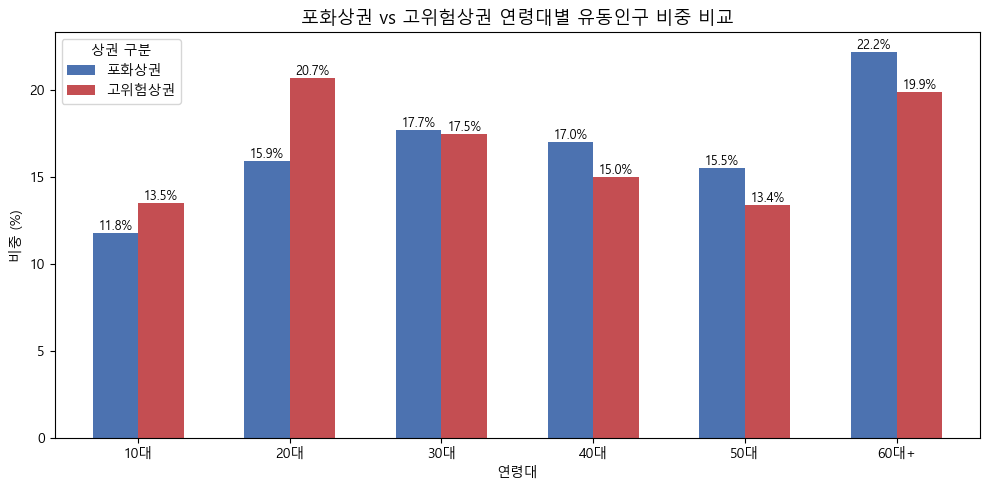

In [17]:
# 포화/고위험 상권 코드 추출
포화_코드 = (포화_상권
            .groupby('상권_코드_명')
            .agg(등장횟수=('연도', 'count'))
            .reset_index()
            .merge(df_합[['상권_코드_명', '상권_코드']].drop_duplicates(), on='상권_코드_명')
            ['상권_코드'].tolist())

고위험_코드 = (고위험_상권[고위험_상권['총점포수'] >= 20]
              .groupby('상권_코드_명')
              .agg(등장횟수=('연도', 'count'))
              .reset_index()
              .query('등장횟수 >= 2')
              .merge(df_합[['상권_코드_명', '상권_코드']].drop_duplicates(), on='상권_코드_명')
              ['상권_코드'].tolist())

# 길단위인구 데이터 불러오기
df_인구2 = pd.read_csv(
    '../data/05_길단위인구/서울시 상권분석서비스(길단위인구-상권).csv',
    encoding='cp949'
)
df_인구2 = df_인구2[df_인구2['기준_년분기_코드'] < 20250]

# 연령대 컬럼
연령대_컬럼 = [
    '연령대_10_유동인구_수',
    '연령대_20_유동인구_수',
    '연령대_30_유동인구_수',
    '연령대_40_유동인구_수',
    '연령대_50_유동인구_수',
    '연령대_60_이상_유동인구_수'
]

# 포화상권 연령대 평균 비중
df_포화_연령 = (df_인구2[df_인구2['상권_코드'].isin(포화_코드)]
               .groupby('상권_코드')[연령대_컬럼].mean().mean())
포화_비중 = (df_포화_연령 / df_포화_연령.sum() * 100).round(1)

# 고위험상권 연령대 평균 비중
df_고위험_연령 = (df_인구2[df_인구2['상권_코드'].isin(고위험_코드)]
                .groupby('상권_코드')[연령대_컬럼].mean().mean())
고위험_비중 = (df_고위험_연령 / df_고위험_연령.sum() * 100).round(1)

# 비교 데이터프레임
df_비교2 = pd.DataFrame({
    '포화상권': 포화_비중.values,
    '고위험상권': 고위험_비중.values
}, index=['10대', '20대', '30대', '40대', '50대', '60대+'])

print(df_비교2)

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))

df_비교2.plot(
    kind='bar',
    ax=ax,
    color=['#4C72B0', '#C44E52'],
    width=0.6
)

ax.set_title('포화상권 vs 고위험상권 연령대별 유동인구 비중 비교', fontsize=13)
ax.set_xlabel('연령대')
ax.set_ylabel('비중 (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='상권 구분')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.tight_layout()
plt.show()